# HW3 : Evaluating Binary Classifiers

### Instructions

The authoritative HW3 instructions are on the course website:

http://www.cs.tufts.edu/cs/135/2026s/hw3.html

Please report any questions to Piazza.

In [69]:
import os
import numpy as np
import pandas as pd

import sklearn.linear_model
import sklearn.metrics
import sklearn.impute 

# Plotting libraries
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', style='whitegrid', font_scale=1.25)

RANDOM_SEED = 68

# Cervical Cancer Risk Screening

In [70]:
# You may need to adjust the path
cervical_cancer_risk_factors = pd.read_csv("risk_factors_cervical_cancer.csv")

# Remove target variable (biopsy) and other diagnostic tests we're not using
X_df = cervical_cancer_risk_factors.drop(columns=["Biopsy"]) #, "Schiller", "Hinselmann"
y = cervical_cancer_risk_factors.Biopsy.to_numpy() 

In [71]:
#Replace all of the "?" with NaN (not a number)
X_df = X_df.replace('?', np.nan)
# We also should make sure that everything is now being treated as numeric, 
# since pandas may have decided columns containing "?" were strings. 
X_df = X_df.apply(pd.to_numeric, errors='coerce')

y = cervical_cancer_risk_factors.Biopsy.to_numpy() 

# Create a train/validation/test split
X_dev, X_test, y_dev, y_test = sklearn.model_selection.train_test_split(
    X_df, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
# Further split the development set into a training and validation set
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(
    X_dev, y_dev, test_size=0.33, random_state=RANDOM_SEED, stratify=y_dev
)
  
print(X_dev.describe())


              Age  Number of sexual partners  First sexual intercourse  \
count  729.000000                 706.000000                723.000000   
mean    26.864198                   2.466006                 17.009682   
std      8.559228                   1.393849                  2.836479   
min     13.000000                   1.000000                 10.000000   
25%     20.000000                   1.000000                 15.000000   
50%     25.000000                   2.000000                 17.000000   
75%     33.000000                   3.000000                 18.000000   
max     84.000000                  15.000000                 32.000000   

       Num of pregnancies      Smokes  Smokes (years)  Smokes (packs/year)  \
count          681.000000  717.000000      717.000000           717.000000   
mean             2.286344    0.142259        1.223111             0.481027   
std              1.472874    0.349560        4.121748             2.349495   
min              0.00

This dataset contains a significant amount of missing data, which is denoted by "?" (we converted them to NaN). 

This is a common occurrence with questionnaire data, especially in a medical context. Asking patients about topics stigmatized in many cultures such as sexual history, birth control, or drug use can result in high non-response rates due to patients be wary of social stigma. Those tasked with collecting questionnaire data may refuse to ask sensitive questions and simply mark them as missing by default. 

When collecting and analyzing data, we need to consider context. Are there large social costs to a patient if they answer this question truthfully? Will they be alone with a clinician or around family when asked this question? Are they answering questions out loud, or filling out written form? These factors may have been taken into account for this questionarre, but generally if we are collecting data via questionnaire we want to **design it in partnership with community members** who understand the context to minimize missing data.  

In [72]:
missing_counts = X_dev.isnull().sum()
missing_percentage = (X_dev.isnull().sum() / len(X_dev)) * 100

# Combine into a clean table
missing_info = pd.concat([missing_counts, missing_percentage], axis=1, keys=['Total Missing', 'Percent'])
print(missing_info.sort_values(by='Percent', ascending=False).head(10))

                                    Total Missing    Percent
STDs: Time since last diagnosis               671  92.043896
STDs: Time since first diagnosis              671  92.043896
IUD                                            99  13.580247
IUD (years)                                    99  13.580247
Hormonal Contraceptives                        90  12.345679
Hormonal Contraceptives (years)                90  12.345679
STDs:syphilis                                  89  12.208505
STDs:vulvo-perineal condylomatosis             89  12.208505
STDs:HPV                                       89  12.208505
STDs:Hepatitis B                               89  12.208505


Here we have two columns, `STDs: Time since first diagnosis` and `STDs: Time since last diagnosis` that are missing for over 90% of values in the training set. Let's drop all columns with more than 60% missing data, which would result in these two columns being dropped. Notice that we exclude the testing set from calculating which columns to drop. 

In [73]:
cols_to_drop = X_dev.columns[X_dev.isna().mean() > 0.60].tolist()
X_dev = X_dev.drop(columns=cols_to_drop)
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

We will *impute* the rest of the missing values in the dataset. Strategies for dealing with missing data could be the topic of an entire course, but for this analysis we will use scikit-learn's [KNNImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html). This imputes missing feature values by calculating the mean of the $k$ nearest other instances by euclidean distance. 

However, imputing this way on the entire dataset before performing a train/test split would result in data leakage, as we would be using information from the test set during training, which could cause us to overestimate how well our trained model generalizes. Instead, we can using `KNNImputer` in a pipeline (along with `MinMaxScaler()`).

In [74]:
"""
Creates a sklearn pipeline for logistic regression with imputation and rescaling steps.
C is the inverse regularization strength, smaller values resulting in higher regularization
Pass in l1_ratio=0 for L2-regularized logit, and l1_ratio=1 for L1-regularized logit
"""
def make_logit_pipeline_knnimpute(C=1.0, k=5):
    pipeline = sklearn.pipeline.Pipeline(
        steps=[
         #('imputer', sklearn.impute.SimpleImputer(missing_values=np.nan, strategy='mean')),
         ('imputer', sklearn.impute.KNNImputer(n_neighbors=k)),
         ('rescaler', sklearn.preprocessing.MinMaxScaler()),
         ('logit', sklearn.linear_model.LogisticRegression(solver="lbfgs", l1_ratio=0, C=C))
        ])
    
    # Return the constructed pipeline
    return pipeline

def make_knn_knnimpute(k_model=5, k_impute=5):
    pipeline = sklearn.pipeline.Pipeline(
        steps=[
         #('imputer', sklearn.impute.SimpleImputer(missing_values=np.nan, strategy='mean')),
         ('imputer', sklearn.impute.KNNImputer(n_neighbors=k_impute)),
         ('rescaler', sklearn.preprocessing.MinMaxScaler()),
         ('knn', sklearn.neighbors.KNeighborsClassifier(n_neighbors=k_model))
        ])
    
    # Return the constructed pipeline
    return pipeline

## Your Code

## Problem 1: Model Creation and Training

1a.
- Calculate and report the class balance in the development set; the proportion of the positive and negative classes. What would the accuracy of a baseline model at always predicts the negative class be in this scenario? Why isn't this model good enough to use for our cancer screening task?

In [91]:
pos_pct = sum(y_dev) / len(y_dev)
neg_pct = 1 - pos_pct
print("Accuracy if model always predicts negative class:", neg_pct)
print("Accuracy if model always predicts positive class:", pos_pct)

Accuracy if model always predicts negative class: 0.9355281207133059
Accuracy if model always predicts positive class: 0.0644718792866941


If our model always predicts the negative class, we would obtain a strong accuracy but predicting negative for all cases would not to be helpful. We would not be able to determine which patients are in need of further care.

1b.
- Train a logistic regression model with regularization using the pipeline creation function included in the starter code. Perform a hyperparameter search using the training and validation sets, selecting the hyperparameter combination that achieves the highest AUCROC on the validation data. Perform a grid search (check all combinations of hyperparameter values) of the regularization strength C and the n_neighbors (k) hyperparameter used for imputing missing data. Note that because our missing data imputation method uses a hyperparamter, we need to search over that in addition to hyperparamters for our main model.


In [76]:
# ranges given in problem definition, score based on sklearn's roc_auc_score functin
# in case of tie, select model with smaller imputation hyperparameter, second tiebreaker of smaller regularization param
C_grid = np.logspace(-4, 4, 17)
k_grid = range(1,18)

In [77]:
best_C, best_k = np.inf, np.inf
best_roc_auc = 0

for C in C_grid:
    for k in k_grid:
        pipeline = make_logit_pipeline_knnimpute(C, k)
        pipeline.fit(X_train, y_train)
        yhat_probs = pipeline.predict_proba(X_val)[:, 1] # get positive class probs
        roc_auc = sklearn.metrics.roc_auc_score(y_val, yhat_probs)

        # update according to tie breaker rules
        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_C, best_k = C, k
        elif roc_auc == best_roc_auc:
            if k < best_k: 
                best_roc_auc = roc_auc
                best_C, best_k = C, k
            elif k == best_k and C < best_C:
                best_roc_auc = roc_auc
                best_C, best_k = C, k
            

In [78]:
print("Best ROC_AUC:", best_roc_auc)
print("Best C:", best_C)
print("Best k:", best_k)

Best ROC_AUC: 0.9416666666666667
Best C: 0.001
Best k: 3


1C. 
- Train a k-nearest neighbors model using the pipeline creation function included in the starter code. Perform a hyperparameter search using the training and validation sets, selecting the hyperparameter combination that achieves the highest AUCROC on the validation data. Perform a grid search (check all combinations of hyperparameter values) of the regularization the n_neighbors hyperparameter used for the actually classifier and the n_neighbors hyperparameter used for imputing missing data. Both should search the same k_grid used above, but be sure that you are checking all combinations of different n_neighbors values. In the case of a tie select the model with a smaller imputation hyperparamter, with a secondary tiebreaker of the smaller classifier n_neighbors value. You may use the same sklearn method mentioned above.



In [79]:
# use same k_grid
best_impute, best_nn = np.inf, np.inf
best_roc_auc_knn = 0

for impute in k_grid:
    for nn in k_grid:

        pipeline = make_knn_knnimpute(nn, impute)
        pipeline.fit(X_train, y_train)
        y_hat = pipeline.predict_proba(X_val)[:, 1]
        roc_auc = sklearn.metrics.roc_auc_score(y_val, y_hat)

        if roc_auc > best_roc_auc_knn:
            best_roc_auc_knn = roc_auc
            best_impute, best_nn = impute, nn
        elif roc_auc == best_roc_auc_knn:
            if impute < best_impute:
                best_roc_auc_knn = roc_auc
                best_impute, best_nn = impute, nn
            elif impute == best_impute and nn < best_nn:
                best_roc_auc_knn = roc_auc
                best_impute, best_nn = impute, nn

In [80]:
print("Best ROC-AUC:", best_roc_auc_knn)
print("Best impute hyperparam:", best_impute)
print("Best n_neighbors val:", best_nn)

Best ROC-AUC: 0.9544444444444444
Best impute hyperparam: 7
Best n_neighbors val: 12


## Problem 2: Choosing a decision threshold from binary classification metrics
2A: ROC Curves
- Plot ROC curves for the best performing logistic regression and k-nearest neighbors models from 1B and 1C on the validation set in the same plot, with the logistic regression model using a red line ("r-") and the k-nearest neighbors model using a blue line ("b-"). Be sure to label your axes (plt.xlabel() and plt.ylabel()) and include a legend (plt.legend()).

In [81]:
best_lr = make_logit_pipeline_knnimpute(best_C, best_k)
best_lr.fit(X_train, y_train)
lr_proba_va = best_lr.predict_proba(X_val)[:, 1]

best_knn = make_knn_knnimpute(best_nn, best_impute)
best_knn.fit(X_train, y_train)
knn_proba_va = best_knn.predict_proba(X_val)[:, 1]

lr_fpr, lr_tpr, lr_thresholds = sklearn.metrics.roc_curve(y_val, lr_proba_va)
knn_fpr, knn_tpr, knn_thresholds = sklearn.metrics.roc_curve(y_val, knn_proba_va)

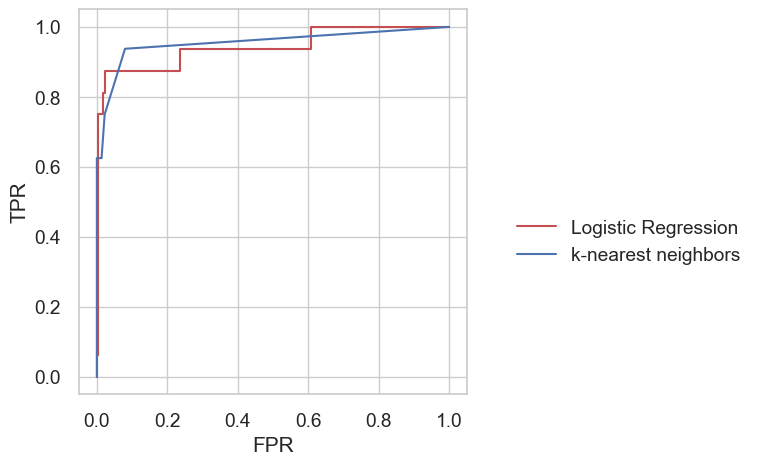

In [82]:
plt.figure(figsize=(5,5))
plt.plot(lr_fpr, lr_tpr, 'r-', label='Logistic Regression')
plt.plot(knn_fpr, knn_tpr, 'b-', label='k-nearest neighbors')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(bbox_to_anchor=(1.75, 0.5))
plt.show()

No model always outperforms the other, they outperform each other at certain tradeoffs

2b. Selecting a decision threshold
- To implement our model for medical decision making we need to choose a threshold at which a biopsy is recommended. One way we can do this is to maximize a binary classification metric under some other performance threshold. For instance, here we may want to maximize the number of true cancer patients found while limiting the number of unneeded biopsies performed.

- Note that roc_curve also returns a list of decision thresholds at each point in the ROC curve. For each of the two trained models, choose a threshold that maximizes TPR while satisfying TNR >= 0.9 on the validation set. Report the two chosen decision thresholds, their corresponding TNR and TPR rates at those thresholds, and which model performs better under this decision thershold. Hint: Recall that 

In [83]:
lr_tnr = 1 - lr_fpr
best_lr_tpr = 0
best_lr_threshold = 0.5
best_lr_tnr = 0
for idx, threshold in enumerate(lr_thresholds):
    if lr_tpr[idx] > best_lr_tpr and lr_tnr[idx] >= 0.9:
        best_lr_tpr = lr_tpr[idx]
        best_lr_threshold = threshold
        best_lr_tnr = lr_tnr[idx]

print("LR Best threshold:", best_lr_threshold)
print("TNR:", best_lr_tnr)
print("TPR:", best_lr_tpr)

knn_tnr = 1 - knn_fpr
best_knn_tpr = 0
best_knn_threshold = 0.5
best_knn_tnr = 0
for idx, threshold in enumerate(knn_thresholds):
    if knn_tpr[idx] > best_knn_tpr and knn_tnr[idx] >= 0.9:
        best_knn_tpr = knn_tpr[idx]
        best_knn_threshold = threshold
        best_knn_tnr = knn_tnr[idx]

print("\nKNN Best threshold:", best_knn_threshold)
print("TNR:", best_knn_tnr)
print("TPR:", best_knn_tpr)

LR Best threshold: 0.06478292382739623
TNR: 0.9777777777777777
TPR: 0.875

KNN Best threshold: 0.08333333333333333
TNR: 0.92
TPR: 0.9375


KNN achieves a higher TPR while satisfying TNR >= 0.9. It is the better model under this performance threshold.

2c: test-set performance
- Using the better-performing model and threshold from 2B, train your model on the full development set and make binary predictions on the test set. Compare these predictions to the corresponding true labels by printing out the confusion matrix (either in a table or as the TP, FP, TN, and FN counts). You can calculate the confusion matrix using sklearn's confusion_matrix function. Be sure to label which of the 4 values is which.

In [84]:
best_model = make_knn_knnimpute(best_nn, best_impute)
best_model.fit(X_dev, y_dev)
proba_test = best_model.predict_proba(X_test)[:, 1]

confusion_matrix = sklearn.metrics.confusion_matrix(y_test, proba_test >= best_knn_threshold)
tn, fp, fn, tp = confusion_matrix.ravel()
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives", fn)
print("True positives:", tp)
print(confusion_matrix)

True negatives: 110
False positives: 11
False negatives 0
True positives: 8
[[110  11]
 [  0   8]]


## Problem 3: Choosing a decision threshold based on cost

Here, we can consider cost of a false negative as the change in mortality based on how much more likely a person is to survive if they receive early treatment for cervical cancer, and the cost of a false positive as the small chance for complications during a biopsy.

3A: Baseline cost
- Calculate the extrapolated mortality cost for two baseline models, a model that predicts all positive and a model that predicts all negatives on the validation set. Report these two costs.

In [85]:
c_fn = 0.7
c_fp = 0.005
population = 1.4e7

# base rate is proportion of positive instances in the validation set
base_rate = sum(y_val) / len(y_val)
print("Base rate:", base_rate)

Base rate: 0.06639004149377593


In [86]:
def calc_cost(fnr, fpr, c_fn=c_fn, c_fp=c_fp, population=population, base_rate=base_rate):
    fn = fnr*base_rate
    fp = fpr*(1-base_rate)
    c_t = ((fn * c_fn) + (fp * c_fp))
    excess_deaths = c_t*population
    return excess_deaths

all_positive = np.ones(y_val.shape)
all_negative = np.zeros(y_val.shape)

pos_fpr, pos_fnr = 1, 0
neg_fpr, neg_fnr = 0, 1


print("Cost for All Positive Model:", calc_cost(pos_fnr, pos_fpr))
print("Cost for All Negative Model:", calc_cost(neg_fnr, neg_fpr))


Cost for All Positive Model: 65352.69709543568
Cost for All Negative Model: 650622.4066390041


3b.
- Find the decision thresholds for each model that minimizes the extrapolated mortality cost on the validation set (using the same hyperparameters you found in question 2). Report the decision threshold, tpr, fpr, and extrapolated mortality cost for the best performing logistic regression threshold and k-nearest neighbors threshold.

In [87]:
best_lr_threshold2 = 0.5
best_lr_tpr2 = 0
best_lr_fpr2 = 0
best_lr_cost = np.inf

for idx, threshold in enumerate(lr_thresholds):
    fnr = 1 - lr_tpr[idx]
    cost = calc_cost(fnr, lr_fpr[idx])
    if cost < best_lr_cost:
        best_lr_cost = cost
        best_lr_threshold2 = threshold
        best_lr_fpr2 = lr_fpr[idx]
        best_lr_tpr2 = lr_tpr[idx]

print("LR Best threshold:", best_lr_threshold2)
print("FPR:", best_lr_fpr2)
print("TPR:", best_lr_tpr2)
print("Mortality Cost:", best_lr_cost)

best_knn_threshold2 = 0.5
best_knn_tpr2 = 0
best_knn_fpr2 = 0
best_knn_cost = np.inf

for idx, threshold in enumerate(knn_thresholds):
    fnr = 1 - knn_tpr[idx]
    cost = calc_cost(fnr, knn_fpr[idx])
    if cost < best_knn_cost:
        best_knn_cost = cost
        best_knn_threshold2 = threshold
        best_knn_fpr2 = knn_fpr[idx]
        best_knn_tpr2 = knn_tpr[idx]

print("\nKNN Best threshold:", best_knn_threshold2)
print("FPR:", best_knn_fpr2)
print("TPR:", best_knn_tpr2)
print("Mortality Cost:", best_knn_cost)



LR Best threshold: 0.06326603021145984
FPR: 0.6088888888888889
TPR: 1.0
Mortality Cost: 39792.53112033196

KNN Best threshold: 0.08333333333333333
FPR: 0.08
TPR: 0.9375
Mortality Cost: 45892.11618257261


Each model outperforms the baselines. LR outperforms the KNN with a lower extrapolated mortality cost. The false positive rate, however, is very high, at 0.6. It would take a lot of resources and time to perform biopsies on so many false positives. 

3C: Test Set Performance
- Train the model you consider better from 3B on the entire development dataset. Using the chosen threshold for this model from 3B, now make binary predictions on the test set and compare them to corresponding true labels by printing out the confusion matrix (either in a table or as the TP, FP, TN, FN). Be sure to label which of the 4 values is which.

- Calculate the mortality cost of this model and compare it to the total mortality cost of a baseline all positive baseline on the test set. Does it do better or worse? Does it do relatively better or worse than the model performed on the validation set?

In [88]:
best_model2 = make_logit_pipeline_knnimpute(best_C, best_k)
best_model2.fit(X_dev, y_dev)
proba_test2 = best_model2.predict_proba(X_test)[:, 1]

confusion_matrix2 = sklearn.metrics.confusion_matrix(y_test, proba_test2 >= best_lr_threshold2)
tn2, fp2, fn2, tp2 = confusion_matrix2.ravel()
print("True negatives:", tn2)
print("False positives:", fp2)
print("False negatives", fn2)
print("True positives:", tp2)
print(confusion_matrix2)

True negatives: 0
False positives: 121
False negatives 0
True positives: 8
[[  0 121]
 [  0   8]]


In [89]:
total_pos_test = np.sum(y_test)
total_neg_test = len(y_test) - total_pos_test

best_model2_cost = calc_cost(fn2 / total_pos_test, fp2 / total_neg_test)
print("Cost:", best_model2_cost)

Cost: 65352.69709543568


This lr model performs exactly the same as the all positive model. This lr model does worse than than thie model performed on the validation set, with a much higher extrapolated mortality cost. 

3D: Changing Base Rates
- Assuming other factors are equal, explore how your optimal decision threshold would change for both models if the HPV vaccine was rolled out and the prevalence of cervical cancer was reduced by 90%. We can simulate this by re-calculating cost with a base positive instance rate by divided by 10, as if the class balance was changed by a factor of 10.

- Using the validation set, report the new decision threshold for your kNN and logistic regression models with this new base rate, and the TPR and FPR at these new thresholds. How did the change in the base positive instance rate affect the decision thresholds (you might need to look past 3 digits to see a change)? Why do you think that is the case?

In [90]:
new_base_rate = base_rate / 10

best_lr_threshold3 = 0.5
best_lr_tpr3 = 0
best_lr_fpr3 = 0
best_lr_cost3 = np.inf

for idx, threshold in enumerate(lr_thresholds):
    fnr = 1 - lr_tpr[idx]
    cost = calc_cost(fnr, lr_fpr[idx], base_rate=new_base_rate)
    if cost < best_lr_cost3:
        best_lr_cost3 = cost
        best_lr_threshold3 = threshold
        best_lr_fpr3 = lr_fpr[idx]
        best_lr_tpr3 = lr_tpr[idx]

print("LR Best threshold:", best_lr_threshold3)
print("FPR:", best_lr_fpr3)
print("TPR:", best_lr_tpr3)
print("Mortality Cost:", best_lr_cost3)

best_knn_threshold3 = 0.5
best_knn_tpr3 = 0
best_knn_fpr3 = 0
best_knn_cost3 = np.inf

for idx, threshold in enumerate(knn_thresholds):
    fnr = 1 - knn_tpr[idx]
    cost = calc_cost(fnr, knn_fpr[idx], base_rate=new_base_rate)
    if cost < best_knn_cost3:
        best_knn_cost3 = cost
        best_knn_threshold3 = threshold
        best_knn_fpr3 = knn_fpr[idx]
        best_knn_tpr3 = knn_tpr[idx]

print("\nKNN Best threshold:", best_knn_threshold3)
print("FPR:", best_knn_fpr3)
print("TPR:", best_knn_tpr3)
print("Mortality Cost:", best_knn_cost3)

LR Best threshold: 0.06478292382739623
FPR: 0.022222222222222223
TPR: 0.875
Mortality Cost: 9678.008298755187

KNN Best threshold: 0.08333333333333333
FPR: 0.08
TPR: 0.9375
Mortality Cost: 9629.21161825726


KNN thresholds did not change but the LR threshold increased slightly. If base rate falls, the cost associated with a single false negative falls (the FN-rate term gets multiplied by a smaller base rate, so trading TPR for TNR becomes for attractive). The LR model is able to raise the threshold slightly. For the KNN, it's threshold grid is coarser, so the optimum sits in the same plateau. 